# scDRS analysis

https://martinjzhang.github.io/scDRS/notebooks/quickstart.html

In [ ]:
# eval "$(conda shell.bash hook)"
# conda init
# conda activate /work/islet_cartography_scrna/scrna_cartography_gwas
# python -m ipykernel install --user --name scrna_cartography_gwas --display-name "gwas"

In [4]:
# Path and system utilities
import os                    # Operating system interface
import sys                   # System-specific parameters and functions
import glob                  # File pattern matching
from pyhere import here      # Reproducible project paths

# dataframes
import pandas as pd
import numpy as np

# Anndata
import anndata as ad
import scanpy as sc
# scDRS
import scdrs

# statistics
from scipy import stats

sys.path.append(str(here('scripts/misc')))  # Add custom script path to system
import misc as mi

In [14]:
mi.create_directories(here("data/gwas/disease_scores"))

/work/islet_cartography_scrna/data/gwas/disease_scores Directory created successfully!


In [22]:
# paths 
base_dir = str(here("data/gwas"))
files_dir =  os.path.join(base_dir, "files")
gs_dir = os.path.join(base_dir, "gs_files")
anndata_dir = str(here('data/anndata/'))
ds_dir = os.path.join(base_dir, "disease_scores")

## Load data

In [5]:
adata = ad.read_h5ad(os.path.join(anndata_dir, "AH_combined.h5ad"))
df_gs = pd.read_csv(os.path.join(gs_dir, "all_traits_geneset.gs"), sep="\t", index_col=0)

### Generate a covariate file (make samples numeric)

In [20]:
adata.obs['ic_id_platform_adjusted_sample'].cat.codes.to_csv(os.path.join(files_dir, 'cov.tsv'), sep = '\t', index_label = 'index')

### Evaluate disease enrichment in individual cells

In [ ]:
# !/work/islet_cartography_scrna/scripts/gwas/AE_disease_enrichment.sh

In [29]:
df_gs.index

Index(['t2d_afa', 't2d_eas', 't2d_sas', 't2d_eur', 't2d_his',
       'handedness_eur'],
      dtype='object', name='TRAIT')

#### overlay the computed scDRS disease scores on the UMAP.

In [42]:
adata.obs['t2d_his'].max()

5.6346774

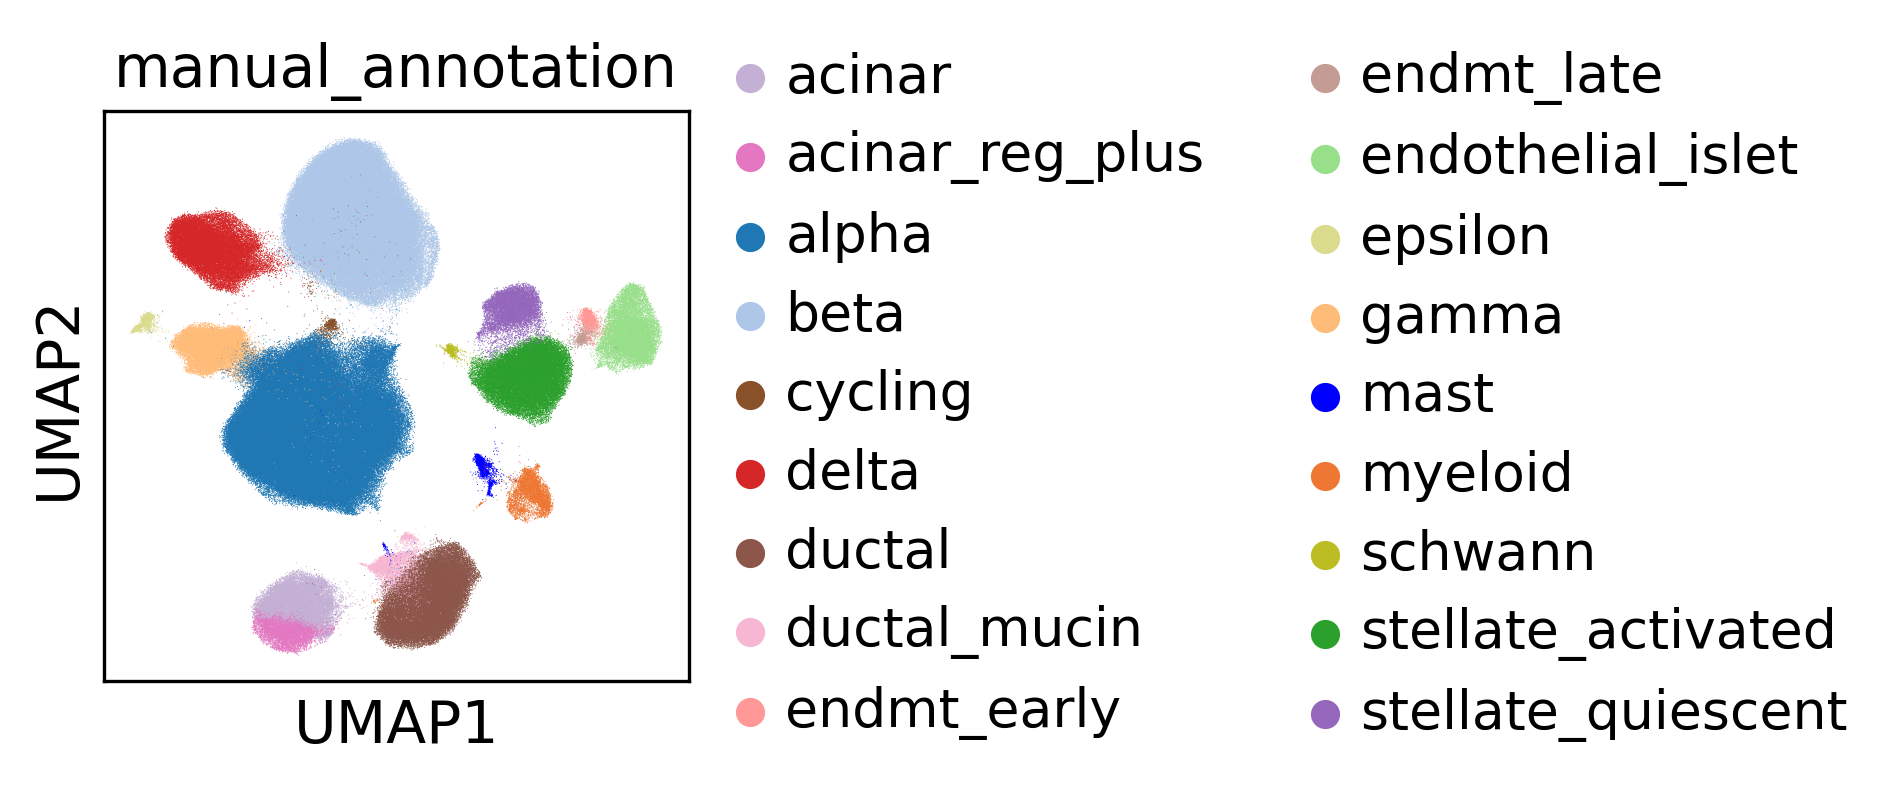

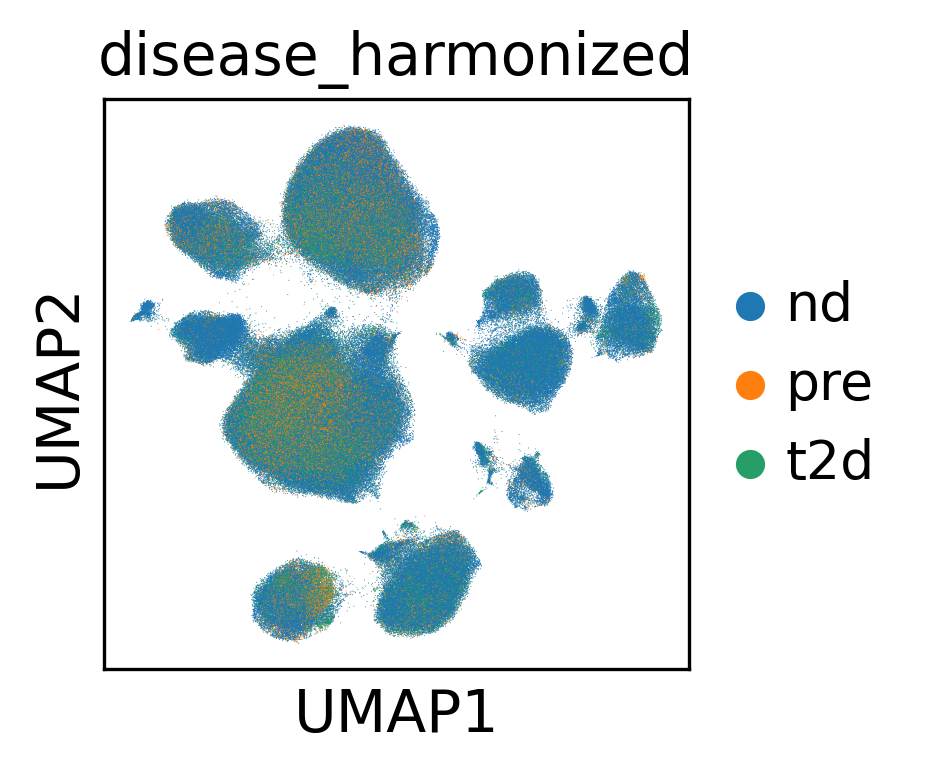

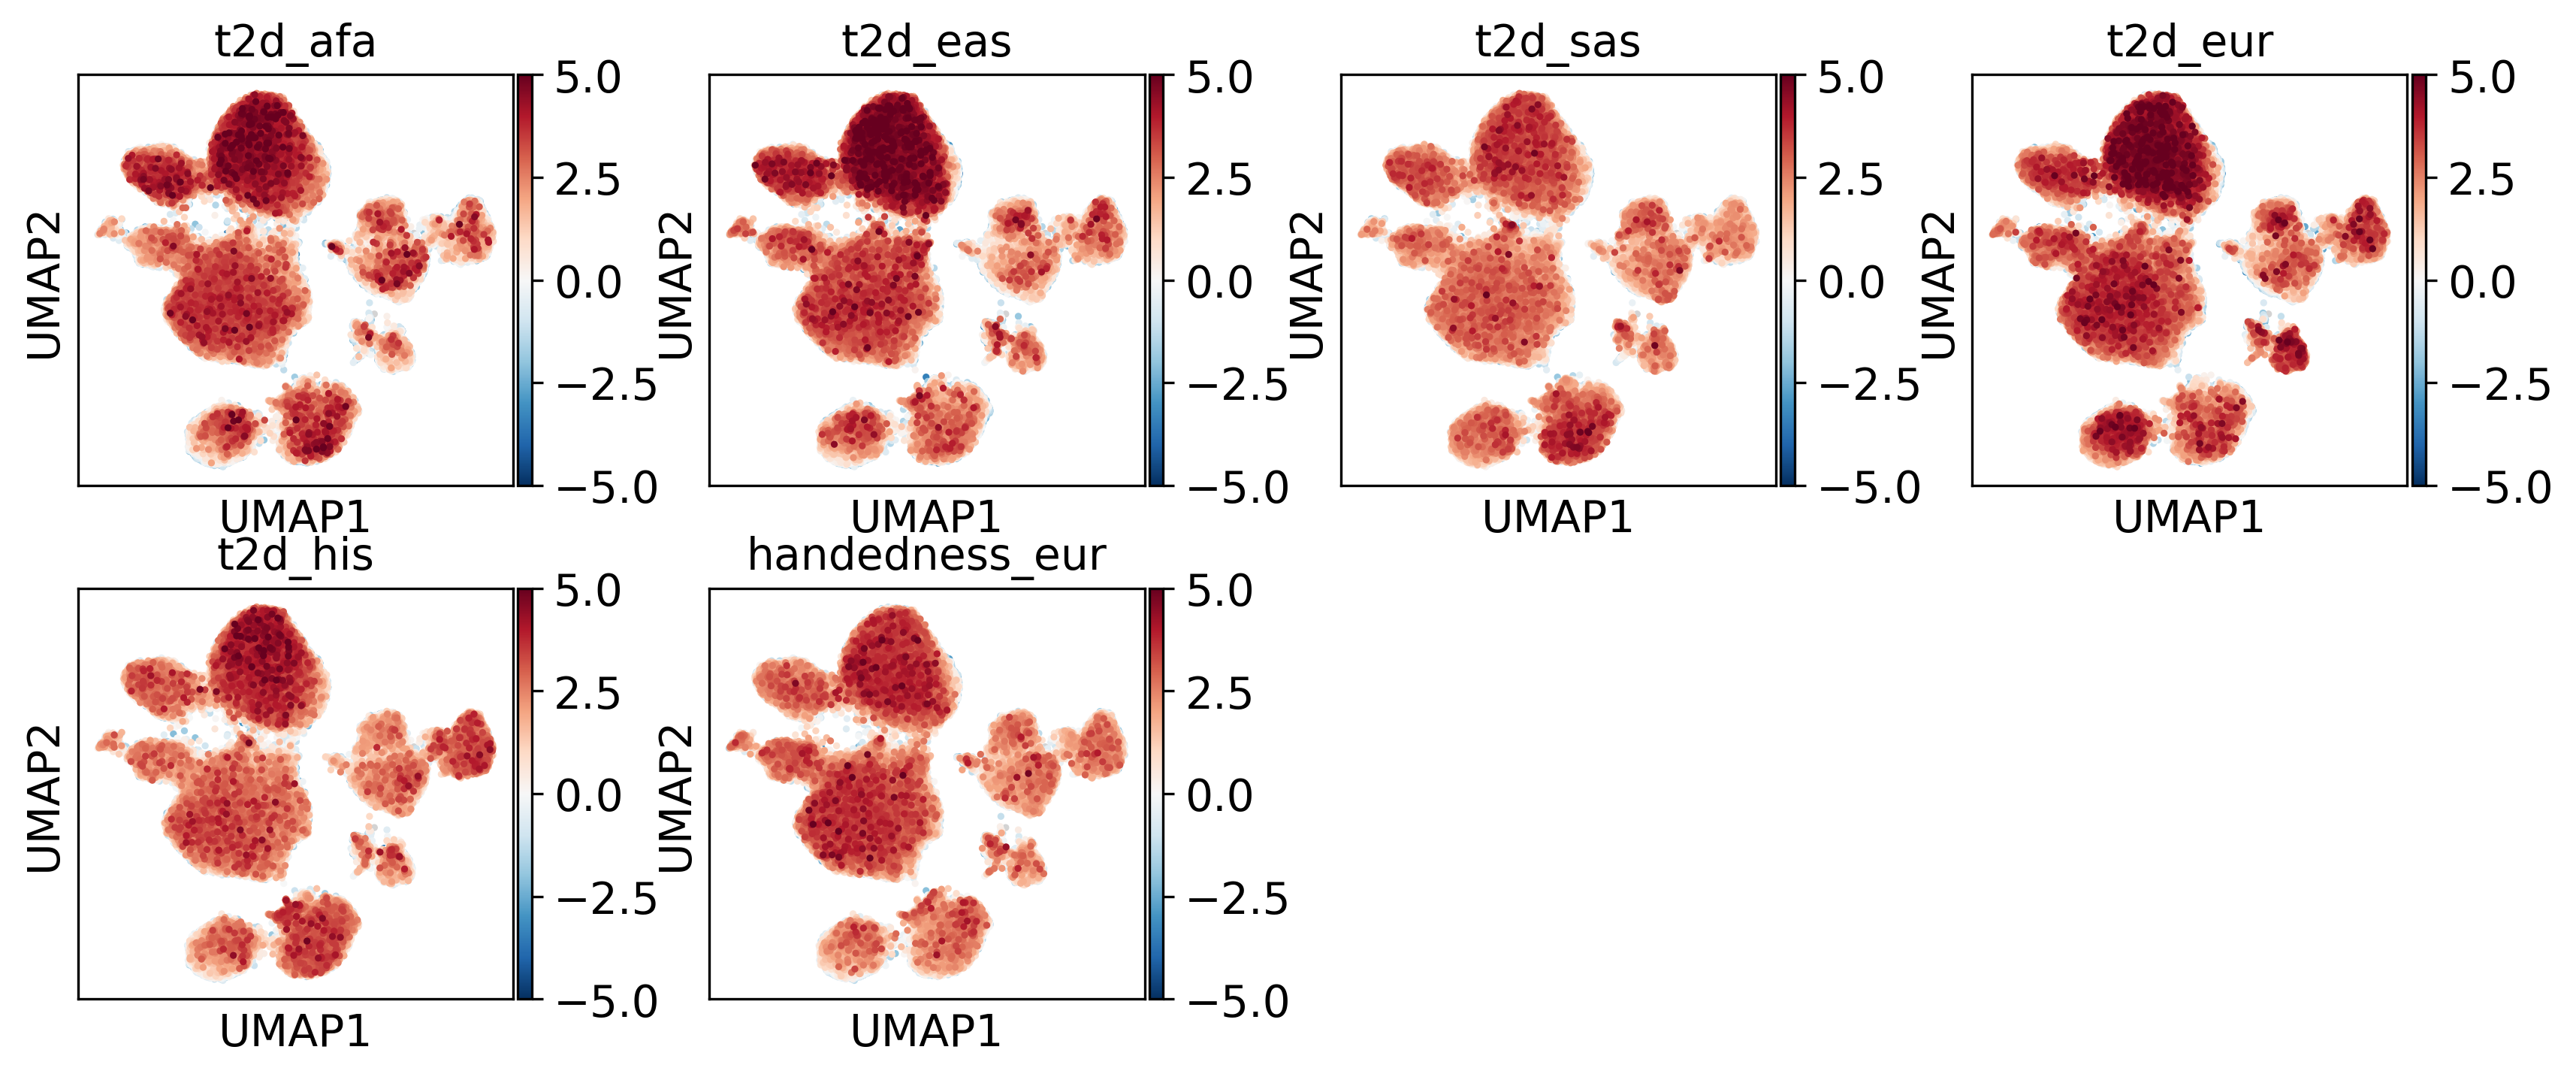

In [34]:
dict_score = {
    trait: pd.read_csv(os.path.join(ds_dir, f"{trait}.full_score.gz"), sep="\t", index_col=0)
    for trait in df_gs.index
}

for trait in dict_score:
    adata.obs[trait] = dict_score[trait]["norm_score"]

sc.set_figure_params(figsize=[2.5, 2.5], dpi=150)
sc.pl.umap(
    adata,
    color="manual_annotation",
    ncols=1,
    vmin=-5,
    vmax=5,
)

sc.pl.umap(
    adata,
    color="disease_harmonized",
    ncols=1,
    vmin=-5,
    vmax=5,
)


sc.pl.umap(
    adata,
    color=dict_score.keys(),
    color_map="RdBu_r",
    vmin=-5,
    vmax=5,
    s=20,
)

In [ ]:
sc.pl.umap(
    adata,
    color=dict_score.keys(),
    color_map="RdBu_r",
    vmin=-5,
    vmax=5,
    s=20,
)

In [50]:
dict_score = {
    trait: pd.read_csv(os.path.join(ds_dir, f"{trait}.full_score.gz"), sep="\t", index_col=0)
    for trait in df_gs.index
}

KeyboardInterrupt: 

In [101]:
score = dict_score["t2d_eur"]['raw_score']

In [102]:
import seaborn as sns

In [103]:
zscore = (score - score.mean())

In [104]:
adata.obs["t2d_eur"] = score

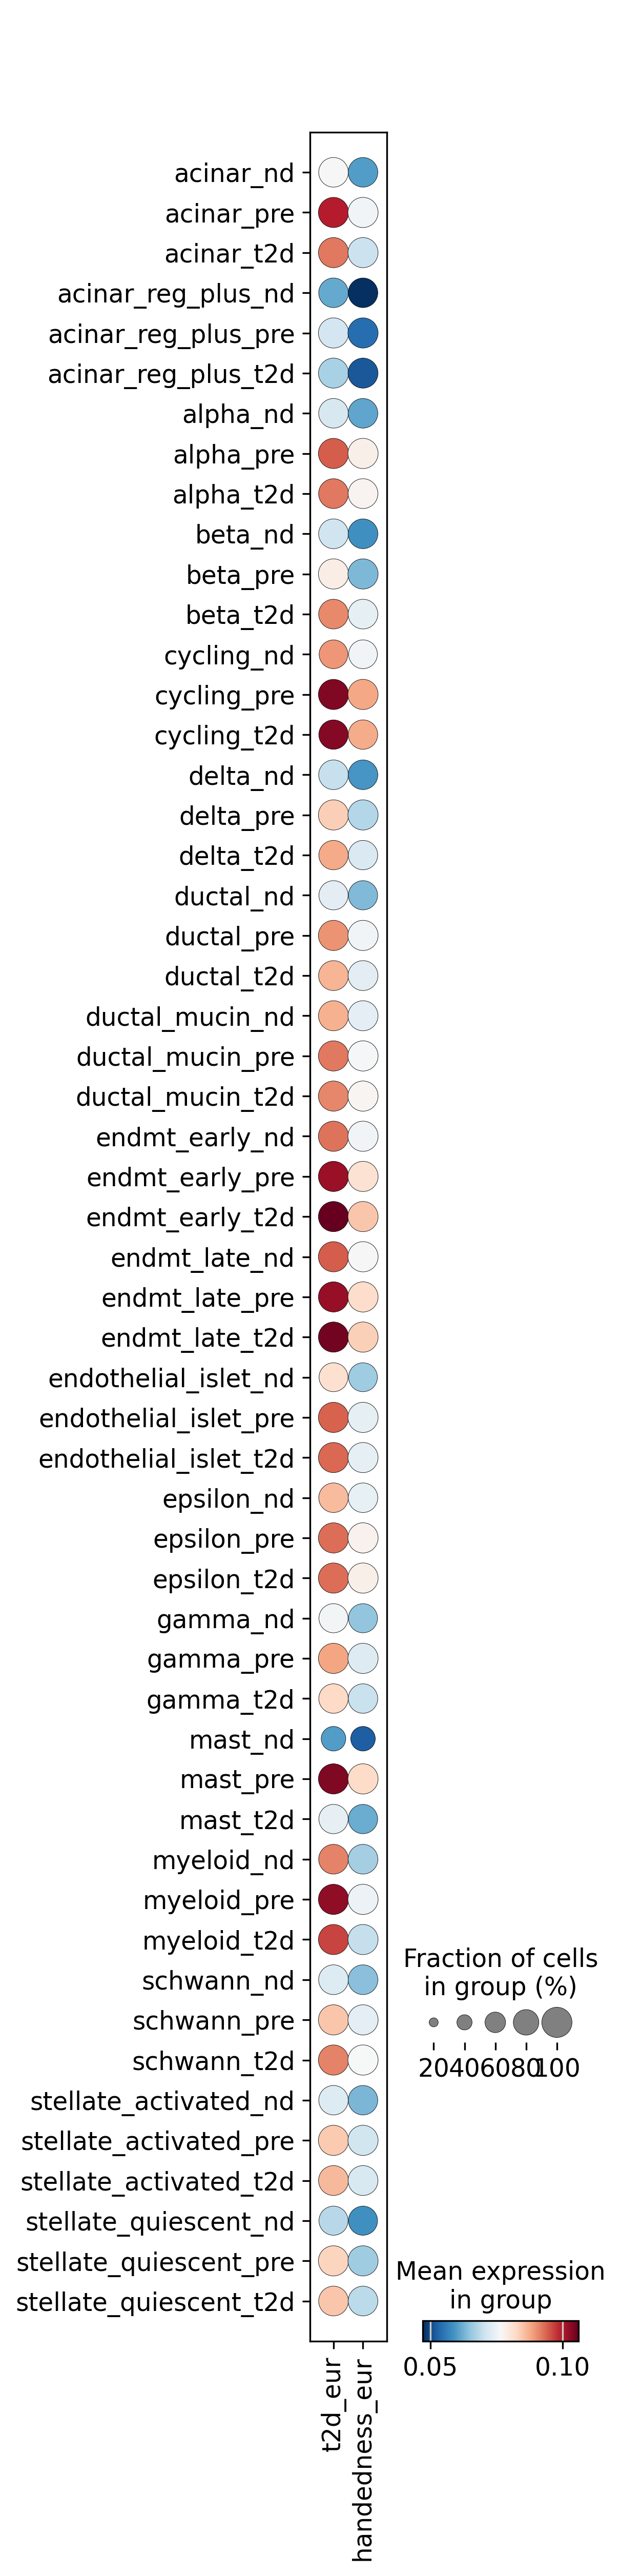

In [109]:
sc.pl.dotplot(adata, var_names = ["t2d_eur","handedness_eur"], color_map="RdBu_r", groupby=["manual_annotation","disease_harmonized"])